# Caso Práctico: _Regresión Logística_

## Conjunto de datos: Predicción de aceptación de una campaña bancaria

### Descripción
Los datos están relacionados con campañas de marketing directo de una institución bancaria portuguesa. Las campañas de marketing se basaron en llamadas telefónicas. En muchos casos fue necesario contactar al mismo cliente más de una vez para determinar si el producto (depósito a plazo fijo) sería suscrito o no.

El objetivo de clasificación es predecir si el cliente suscribirá un depósito a plazo (variable y: yes/no). El conjunto de datos contiene 41 188 instancias con 20 variables de entrada (combinación de numéricas y categóricas) y 1 etiqueta de salida binaria.

**Fuente:** Moro, S., Cortez, P., & Rita, P. (2014). A data-driven approach to predict the success of bank telemarketing. Decision Support Systems, 62, 22-31.

## Algoritmo: Regresión Logística

La **Regresión Logística** es un algoritmo de aprendizaje supervisado utilizado para problemas de **clasificación binaria**. A pesar de su nombre, no es un regresor sino un clasificador: estima la probabilidad de que una instancia pertenezca a una clase aplicando la **función sigmoide** (σ) a una combinación lineal de las características.

### ¿Cómo funciona?

1. Calcula una puntuación lineal: `z = w₀x₀ + w₁x₁ + … + wₙxₙ + b`
2. Aplica la función sigmoide para obtener una probabilidad: `p = σ(z) = 1 / (1 + e⁻ᶻ)`
3. Si `p ≥ 0.5` → predice clase positiva (`yes`); si `p < 0.5` → predice clase negativa (`no`)

La frontera de decisión es la recta (o hiperplano en alta dimensión) donde `z = 0`, es decir, donde la probabilidad predicha es exactamente 0,5.

### ¿Por qué Regresión Logística para este problema?

| Característica | Ventaja en este caso |
|---|---|
| Interpretabilidad | Los coeficientes indican el peso de cada variable (edad, duración de la llamada, etc.) |
| Eficiencia | Entrena rápido sobre los 41 188 registros |
| Probabilidades | Devuelve probabilidades, útil para ajustar el umbral de decisión |
| Regularización | L1 y L2 permiten controlar el sobreajuste y seleccionar variables |

### Hiperparámetros clave

- **`C`**: inverso de la regularización. `C` pequeño → más regularización → coeficientes más pequeños. `C` grande → menos regularización → posible sobreajuste.
- **`penalty`**: tipo de regularización — `'l2'` (por defecto, penaliza coeficientes grandes) o `'l1'` (fuerza algunos coeficientes a cero, selección de variables).
- **`solver`**: algoritmo de optimización — `'lbfgs'` (por defecto, compatible con L2) o `'liblinear'` (necesario para L1).
- **`max_iter`**: número máximo de iteraciones del optimizador.

## Imports

Se importan las librerías necesarias: `pandas` y `numpy` para el manejo de datos, `matplotlib` para la visualización gráfica, y los módulos de `scikit-learn` para preprocesamiento, modelado y evaluación.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

Se suprimen advertencias de convergencia que puede emitir scikit-learn durante el entrenamiento. No afectan al resultado.

In [2]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

## Funciones auxiliares

**`train_val_test_split`** — divide el dataset completo en tres partes con la proporción **60 % entrenamiento / 20 % validación / 20 % prueba**. El parámetro `stratify` garantiza que la proporción de clases (`yes`/`no`) se mantenga igual en los tres subconjuntos, lo cual es importante cuando el dataset está desbalanceado.

In [3]:
# Construcción de una función que realice el particionado completo
def train_val_test_split(df, rstate=42, shuffle=True, stratify=None):
    strat = df[stratify] if stratify else None
    train_set, test_set = train_test_split(
        df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify else None
    val_set, test_set = train_test_split(
        test_set, test_size=0.5, random_state=rstate, shuffle=shuffle, stratify=strat)
    return (train_set, val_set, test_set)

**`remove_labels`** — separa el DataFrame en la matriz de características `X` (todas las columnas menos la etiqueta) y el vector de etiquetas `y`. Se llamará una vez por cada subconjunto (entrenamiento, validación y prueba).

In [5]:
def remove_labels(df, label_name):
    X = df.drop(label_name, axis=1)
    y = df[label_name].copy()
    return (X, y)

**`evaluate_result`** — imprime la misma métrica (p. ej. F1) para dos configuraciones: el modelo **sin preparación** y el modelo **con preparación**. Permite comparar de un vistazo si el preprocesamiento mejora el rendimiento.

In [6]:
def evaluate_result(y_pred, y, y_prep_pred, y_prep, metric):
    print(metric.__name__, "SIN preparación:", metric(y_pred, y, pos_label="yes"))
    print(metric.__name__, "CON preparación:", metric(y_prep_pred, y_prep, pos_label="yes"))

**`plot_lr_decision_boundary`** — calcula y traza la frontera de decisión lineal de la Regresión Logística en 2D. La ecuación de la frontera es `w₀·x₀ + w₁·x₁ + b = 0`; despejando `x₁` se obtiene la recta que se superpone al gráfico de dispersión.

In [7]:
# Representación gráfica del límite de decisión de la regresión logística
def plot_lr_decision_boundary(lr_clf, xmin, xmax):
    w = lr_clf.coef_[0]
    b = lr_clf.intercept_[0]
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0]/w[1] * x0 - b/w[1]
    plt.plot(x0, decision_boundary, "k-", linewidth=2, label="Frontera de decisión")

## 1. Lectura del conjunto de datos

Se carga el dataset desde el archivo CSV. El parámetro `sep=";"` es necesario porque el fichero *Bank Marketing* usa punto y coma como separador. **Resultado esperado:** un `DataFrame` con 41 188 filas y 21 columnas.

In [9]:
df = pd.read_csv("bank-additional-full.csv", sep=";")

## 2. Visualización preliminar de la información

**Resultado esperado:** tabla con las primeras 10 filas del dataset. Permite inspeccionar los valores de cada columna y confirmar que la carga fue correcta.

In [10]:
df.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


**Resultado esperado:** estadísticas descriptivas (media, desviación estándar, mínimo, percentiles y máximo) de las columnas numéricas. Revela rangos muy distintos entre variables (por ejemplo `duration` en segundos frente a `age` en años), lo que motivará el escalado posterior.

In [11]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


**Resultado esperado:** listado de columnas con su tipo de dato (`int64`, `float64`, `object`) y el número de valores no nulos. Las columnas de tipo `object` son las categóricas que se deberán codificar antes de entrenar el modelo.

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

**Resultado esperado:** recuento de la variable objetivo `y`. El dataset está desbalanceado: aproximadamente el **88 % son `no`** y el **12 % son `yes`**. Por eso se usará F1 Score en lugar de accuracy para evaluar el modelo.

In [13]:
df["y"].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

Se verifica si existen valores `NaN` en el dataset. **Resultado esperado:** la celda no muestra nada (serie vacía), lo que confirma que no hay nulos reales. Los valores desconocidos aparecen como la cadena `"unknown"` en columnas categóricas, no como `NaN`.

In [14]:
# Comprobación de si existen valores nulos
is_null = df.isna().any()
is_null[is_null]

Series([], dtype: bool)

Se verifica si existen valores infinitos (`inf`, `-inf`). **Resultado esperado:** serie vacía, confirmando que el dataset no contiene infinitos.

In [15]:
# Comprobación de la existencia de valores infinitos
is_inf = df.isin([np.inf, -np.inf]).any()
is_inf[is_inf]

Series([], dtype: bool)

**Gráfico de dispersión** de `age` (eje X) frente a `duration` — duración de la última llamada en segundos (eje Y). Los **puntos verdes (×)** son clientes que aceptaron el depósito (`yes`) y los **rojos (·)** los que lo rechazaron (`no`). Se observa que las llamadas más largas tienden a coincidir con aceptaciones, aunque la separación no es limpia con solo dos variables.

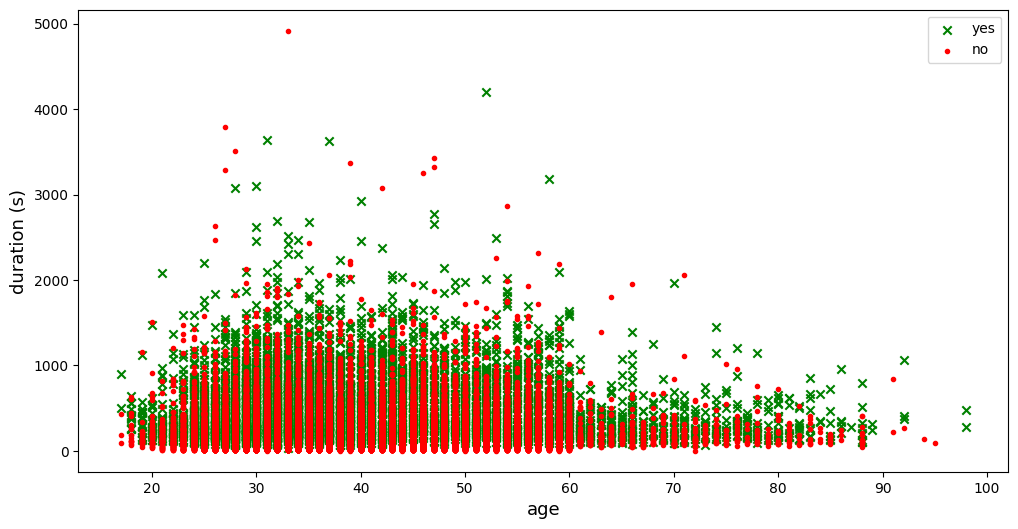

In [16]:
# Representación gráfica de dos características numéricas
plt.figure(figsize=(12, 6))
plt.scatter(df["age"][df["y"] == "yes"], df["duration"][df["y"] == "yes"], c="g", marker="x", label="yes")
plt.scatter(df["age"][df["y"] == "no"], df["duration"][df["y"] == "no"], c="r", marker=".", label="no")
plt.xlabel("age", fontsize=13)
plt.ylabel("duration (s)", fontsize=13)
plt.legend()
plt.show()

## 3. División del conjunto de datos

Se aplica la función de particionado con `stratify='y'` para preservar la proporción de clases en cada subconjunto. **Resultado:** tres DataFrames — `train_set` (≈24 712 filas), `val_set` (≈8 238 filas) y `test_set` (≈8 238 filas).

In [17]:
# División estratificada 60/20/20 para mantener proporciones de clase
train_set, val_set, test_set = train_val_test_split(df, stratify="y")

Se separan las características (`X`) de la etiqueta (`y`) en los tres subconjuntos. A partir de aquí se trabaja siempre con `X_train`/`y_train`, `X_val`/`y_val` y `X_test`/`y_test` de forma independiente.

In [18]:
X_train, y_train = remove_labels(train_set, "y")
X_val, y_val = remove_labels(val_set, "y")
X_test, y_test = remove_labels(test_set, "y")

## 4. Preparación del conjunto de datos

La Regresión Logística solo acepta valores numéricos. Se identifican automáticamente las columnas de tipo `object` (texto) que necesitan codificación. **Resultado esperado:** `['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']`.

In [19]:
# Identificación de columnas categóricas
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
print("Columnas categóricas:", cat_cols)

Columnas categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


/tmp/ipykernel_9168/341418105.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include="object").columns.tolist()


`OrdinalEncoder` convierte cada valor de texto en un número entero (por ejemplo: `admin.` → 0, `blue-collar` → 1…). Se hace `fit_transform` en cada subconjunto para aprender el mapeo. **Resultado esperado:** las columnas categóricas pasan a contener valores numéricos enteros.

In [20]:
# Codificación ordinal de variables categóricas
encoder = OrdinalEncoder()
X_train_prep = X_train.copy()
X_train_prep[cat_cols] = encoder.fit_transform(X_train[cat_cols])

X_val_prep = X_val.copy()
X_val_prep[cat_cols] = encoder.fit_transform(X_val[cat_cols])

X_test_prep = X_test.copy()
X_test_prep[cat_cols] = encoder.fit_transform(X_test[cat_cols])

`SimpleImputer` con estrategia `median` rellena posibles valores nulos con la mediana de cada columna. Se crea el objeto aquí pero todavía no se aplica.

In [21]:
# Imputación de valores nulos con la mediana
imputer = SimpleImputer(strategy="median")

Se aplica el imputador a los tres subconjuntos y se restaura el resultado como `DataFrame` de pandas para conservar nombres de columna e índices. **Resultado esperado:** arrays completamente numéricos y sin valores nulos.

In [22]:
X_train_prep = pd.DataFrame(
    imputer.fit_transform(X_train_prep),
    columns=X_train_prep.columns, index=y_train.index)
X_val_prep = pd.DataFrame(
    imputer.fit_transform(X_val_prep),
    columns=X_val_prep.columns, index=y_val.index)
X_test_prep = pd.DataFrame(
    imputer.fit_transform(X_test_prep),
    columns=X_test_prep.columns, index=y_test.index)

**Resultado esperado:** tabla igual que `df.head(10)` pero con todas las columnas categóricas ya convertidas a números enteros. Permite confirmar que la codificación se aplicó correctamente.

In [23]:
X_train_prep.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
4966,35.0,0.0,1.0,6.0,1.0,2.0,0.0,1.0,6.0,4.0,86.0,2.0,999.0,0.0,1.0,1.1,93.994,-36.4,4.858,5191.0
3248,42.0,11.0,0.0,3.0,0.0,0.0,0.0,1.0,6.0,2.0,57.0,2.0,999.0,0.0,1.0,1.1,93.994,-36.4,4.860,5191.0
828,45.0,1.0,1.0,2.0,1.0,2.0,2.0,1.0,6.0,4.0,207.0,1.0,999.0,0.0,1.0,1.1,93.994,-36.4,4.856,5191.0
12923,27.0,0.0,2.0,3.0,0.0,0.0,0.0,0.0,3.0,3.0,185.0,1.0,999.0,0.0,1.0,1.4,93.918,-42.7,4.962,5228.1
37094,51.0,0.0,1.0,6.0,0.0,2.0,0.0,0.0,3.0,0.0,139.0,5.0,999.0,0.0,1.0,-2.9,92.469,-33.6,0.921,5076.2
38382,54.0,3.0,1.0,5.0,0.0,0.0,0.0,1.0,8.0,1.0,187.0,2.0,999.0,0.0,1.0,-3.4,92.431,-26.9,0.739,5017.5
25921,32.0,2.0,1.0,6.0,0.0,0.0,2.0,0.0,7.0,4.0,49.0,2.0,999.0,1.0,0.0,-0.1,93.200,-42.0,4.120,5195.8
14356,27.0,7.0,2.0,3.0,0.0,0.0,0.0,0.0,3.0,1.0,1071.0,3.0,999.0,0.0,1.0,1.4,93.918,-42.7,4.962,5228.1
9406,35.0,9.0,1.0,5.0,1.0,2.0,0.0,1.0,4.0,0.0,34.0,2.0,999.0,0.0,1.0,1.4,94.465,-41.8,4.967,5228.1
10821,24.0,2.0,1.0,6.0,0.0,2.0,2.0,1.0,4.0,4.0,126.0,4.0,999.0,0.0,1.0,1.4,94.465,-41.8,4.962,5228.1


**Resultado esperado:** serie vacía, confirmando que el preprocesamiento eliminó cualquier valor nulo y el dataset está listo para el entrenamiento.

In [24]:
# Verificación de valores nulos tras la preparación
is_null = X_train_prep.isna().any()
is_null[is_null]

Series([], dtype: bool)

## 5. Regresión Logística: sin escalado

### 5.1 Conjunto de datos reducido

Para poder **visualizar la frontera de decisión en 2D**, se reduce el dataset a solo dos características: `age` y `duration`. En alta dimensión (20 features) la frontera es un hiperplano que no se puede representar gráficamente.

In [25]:
# Reducción a dos características para representación gráfica
X_train_reduced = X_train_prep[["age", "duration"]].copy()
X_val_reduced = X_val_prep[["age", "duration"]].copy()

**Resultado esperado:** `DataFrame` con únicamente las columnas `age` y `duration` del conjunto de entrenamiento.

In [26]:
X_train_reduced

,age,duration
4966,35.0,86.0
3248,42.0,57.0
828,45.0,207.0
12923,27.0,185.0
37094,51.0,139.0
...,...,...
40205,28.0,192.0
7494,29.0,165.0
10747,35.0,544.0
37818,80.0,323.0


Se entrena la Regresión Logística sobre el subconjunto reducido (solo `age` y `duration`). `max_iter=1000` evita avisos de convergencia. **Resultado esperado:** objeto `LogisticRegression` ajustado, con coeficientes `coef_` e intercepto `intercept_` disponibles.

In [27]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_reduced, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

**Gráfico de la frontera de decisión** sobre el conjunto de entrenamiento reducido. Los **puntos verdes (×)** son `yes` y los **rojos (·)** son `no`. La **línea negra continua** es la frontera lineal donde la probabilidad predicha es exactamente 0,5. Con solo dos variables la mayoría de puntos `yes` se mezclan con los `no`, por lo que la separación es limitada.

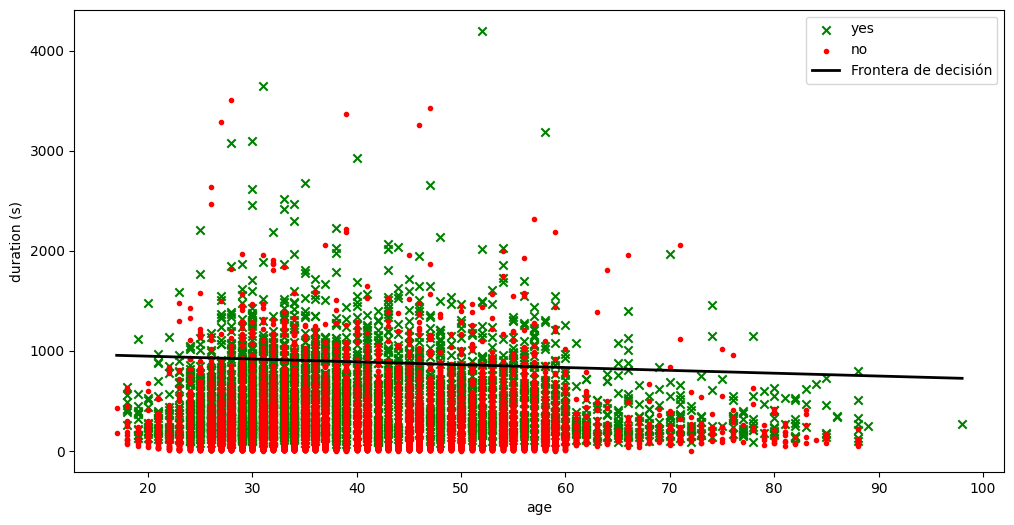

In [28]:
plt.figure(figsize=(12, 6))
plt.scatter(X_train_reduced["age"][y_train == "yes"],
            X_train_reduced["duration"][y_train == "yes"], c="g", marker="x", label="yes")
plt.scatter(X_train_reduced["age"][y_train == "no"],
            X_train_reduced["duration"][y_train == "no"], c="r", marker=".", label="no")
plot_lr_decision_boundary(log_reg,
    X_train_reduced["age"].min(), X_train_reduced["age"].max())
plt.xlabel("age")
plt.ylabel("duration (s)")
plt.legend()
plt.show()

Se predice sobre el conjunto de validación reducido y se calcula el **F1 Score** para la clase positiva (`yes`). **Resultado esperado:** valor bajo (en torno a 0.30–0.45) porque el modelo dispone de muy poca información con solo dos variables.

In [29]:
y_pred = log_reg.predict(X_val_reduced)
print("F1 Score:", f1_score(y_pred, y_val, pos_label="yes"))

F1 Score: 0.24625623960066556


### 5.2 Conjunto de datos completo

Ahora se entrena la Regresión Logística con el **dataset completo** (20 features codificados). Al disponer de más información, el modelo debería mejorar respecto al conjunto reducido.

In [30]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_prep, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

**Resultado esperado:** F1 Score claramente superior al del conjunto reducido, aunque sin escalar el optimizador puede tener dificultades por los rangos muy distintos entre variables.

In [31]:
y_pred = log_reg.predict(X_val_prep)
print("F1 Score:", f1_score(y_pred, y_val, pos_label="yes"))

F1 Score: 0.5046480743691899


## 6. Regresión Logística: con escalado

### 6.1 Solver lbfgs con regularización L2 (por defecto)

Se construye un **Pipeline** que encadena `RobustScaler` y `LogisticRegression`. `RobustScaler` normaliza usando la mediana y el rango intercuartílico, haciéndolo robusto ante valores extremos. Se entrena primero sobre el **conjunto reducido** para poder visualizar la frontera.

In [32]:
log_reg_sc = Pipeline([
    ("scaler", RobustScaler()),
    ("log_reg", LogisticRegression(random_state=42, max_iter=1000))
])
log_reg_sc.fit(X_train_reduced, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('log_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['no','yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['age','duration']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"


**Gráfico de la frontera de decisión con escalado.** La línea puede desplazarse ligeramente respecto a la versión sin escalar, porque el escalado cambia las magnitudes relativas de las variables y el peso aprendido por el modelo.

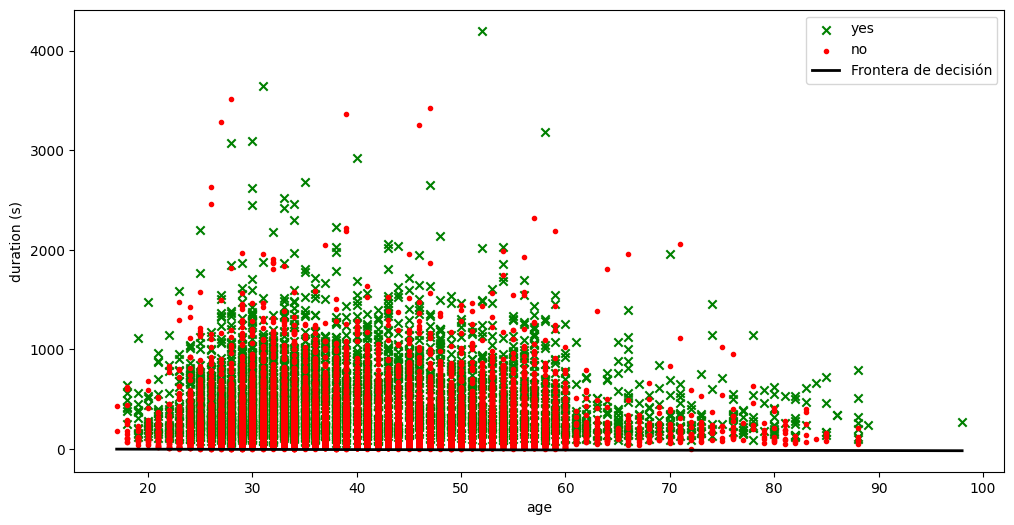

In [33]:
plt.figure(figsize=(12, 6))
plt.scatter(X_train_reduced["age"][y_train == "yes"],
            X_train_reduced["duration"][y_train == "yes"], c="g", marker="x", label="yes")
plt.scatter(X_train_reduced["age"][y_train == "no"],
            X_train_reduced["duration"][y_train == "no"], c="r", marker=".", label="no")
plot_lr_decision_boundary(log_reg_sc.named_steps["log_reg"],
    X_train_reduced["age"].min(), X_train_reduced["age"].max())
plt.xlabel("age")
plt.ylabel("duration (s)")
plt.legend()
plt.show()

**Resultado esperado:** F1 Score similar al obtenido sin escalar sobre el conjunto reducido. El escalado tiene más impacto cuando se utiliza el dataset completo con features de rangos muy distintos.

In [34]:
y_pred_reduced_sc = log_reg_sc.predict(X_val_reduced)
print("F1 Score:", f1_score(y_pred_reduced_sc, y_val, pos_label="yes"))

F1 Score: 0.24625623960066556


Se reentrena el mismo pipeline pero ahora con el **dataset completo** (20 features). Esta es la configuración que debería ofrecer el mejor rendimiento del modelo.

In [35]:
log_reg_sc = Pipeline([
    ("scaler", RobustScaler()),
    ("log_reg", LogisticRegression(random_state=42, max_iter=1000))
])
log_reg_sc.fit(X_train_prep, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('log_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['no','yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['age','job','marital',...,'cons.conf.idx','euribor3m','nr.employed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"


**Resultado esperado:** F1 Score igual o superior al obtenido sin escalado en la sección 5.2. El escalado mejora la convergencia del optimizador y equilibra la influencia de variables con rangos muy distintos.

In [36]:
y_prep_pred = log_reg_sc.predict(X_val_prep)
print("F1 Score:", f1_score(y_prep_pred, y_val, pos_label="yes"))

F1 Score: 0.5121790651744569


### 6.2 Solver liblinear con regularización L1

La **regularización L1** (Lasso) penaliza la suma de los valores absolutos de los coeficientes, forzando a algunos a ser exactamente cero. Esto actúa como **selección automática de características**. El solver `liblinear` es el único compatible con L1. `C=1` controla la intensidad (valores menores → más regularización → más coeficientes a cero).

In [37]:
log_reg_l1 = Pipeline([
    ("scaler", RobustScaler()),
    ("log_reg", LogisticRegression(penalty="l1", solver="liblinear",
                                    C=1, random_state=42, max_iter=1000))
])
log_reg_l1.fit(X_train_prep, y_train)

/home/hisoka/Escritorio/topicoD/topicos-d/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('log_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['no','yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['age','job','marital',...,'cons.conf.idx','euribor3m','nr.employed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"


**Resultado esperado:** F1 Score comparable al de L2. Si hay variables poco informativas, L1 puede mejorar el resultado al anularlas. Si todas aportan, los resultados serán similares.

In [38]:
y_pred_l1 = log_reg_l1.predict(X_val_prep)
print("F1 Score:", f1_score(y_pred_l1, y_val, pos_label="yes"))

F1 Score: 0.5079155672823219


### 6.3 Evaluación comparativa

**Comparación final** entre el modelo sin escalar (sección 5.2) y el modelo con escalado L2 (sección 6.1) usando la función `evaluate_result`. **Resultado esperado:** el F1 `CON preparación` debería ser igual o superior al `SIN preparación`, confirmando que el escalado aporta valor al modelo.

In [39]:
evaluate_result(y_pred, y_val, y_prep_pred, y_val, f1_score)

f1_score SIN preparación: 0.5046480743691899
f1_score CON preparación: 0.5121790651744569
